Normalized values:
-14.000000
-12.000000
-10.000000
-8.000000
-7.000000
-6.000000
-5.000000
-4.000000
-3.500000
-3.000000
-2.500000
-2.000000
-1.750000
-1.500000
-1.250000
-1.000000
-0.875000
-0.750000
-0.625000
-0.500000
-0.437500
-0.375000
-0.312500
-0.250000
0.250000
0.312500
0.375000
0.437500
0.500000
0.625000
0.750000
0.875000
1.000000
1.250000
1.500000
1.750000
2.000000
2.500000
3.000000
3.500000
4.000000
5.000000
6.000000
7.000000
8.000000
10.000000
12.000000
14.000000

Denormalized values:
-0.187500
-0.125000
-0.062500
0.000000
-0.000000
0.062500
0.125000
0.187500


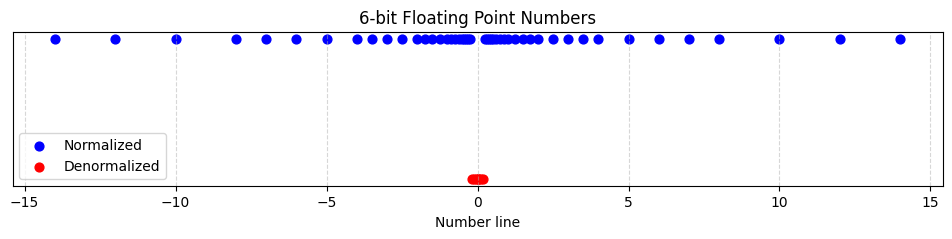

In [1]:
import matplotlib.pyplot as plt

def compute_normalized_values():
    values = []
    exponents = range(1, 7)  # exponent bits 001 to 110
    fractions = [0.0, 0.25, 0.5, 0.75]
    bias = 3

    for sign in [-1, 1]:
        for e_bits in exponents:
            exp = e_bits - bias
            for frac in fractions:
                val = sign * (1 + frac) * (2 ** exp)
                values.append(val)
    return values

def compute_denormalized_values():
    values = []
    exponent_value = -2  # when exponent bits are 000 → interpreted as 2^(1 - bias)
    mantissas = [0.25, 0.5, 0.75]  # skip 0 (zero is special)

    for sign in [-1, 1]:
        for frac in mantissas:
            val = sign * frac * (2 ** exponent_value)
            values.append(val)

    # Optional: include +0 and -0 explicitly
    values.append(0.0)
    values.append(-0.0)

    return values

# Get both sets
normalized_vals = compute_normalized_values()
denormalized_vals = compute_denormalized_values()

# Combine and sort
all_vals = sorted(normalized_vals + denormalized_vals)

# Print them
print("Normalized values:")
for v in sorted(normalized_vals):
    print(f"{v:.6f}")

print("\nDenormalized values:")
for v in sorted(denormalized_vals):
    print(f"{v:.6f}")

# Plot
plt.figure(figsize=(12, 2))
plt.scatter(normalized_vals, [0.5]*len(normalized_vals), color='blue', label='Normalized', s=40)
plt.scatter(denormalized_vals, [-0.5]*len(denormalized_vals), color='red', label='Denormalized', s=40)
plt.yticks([])
plt.title("6-bit Floating Point Numbers")
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.xlabel("Number line")
plt.show()
